In [1]:
# --- preparação do ambiente (rode esta célula primeiro) ---
# Acha a raiz do projeto; se não existir, estamos no Colab e o repositório é clonado.
import os
import pathlib
import subprocess

REPOSITORIO = "https://github.com/thxggz/dr1-at-algoritmos.git"
DESTINO_CLONE = pathlib.Path("/content/dr1-at-algoritmos")


def raiz_do_projeto() -> pathlib.Path | None:
    """Primeiro diretório, subindo a partir do atual, que contenha src/counters.py."""
    for base in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]:
        if (base / "src" / "counters.py").exists():
            return base
    return None


raiz = raiz_do_projeto()
if raiz is None:
    if not DESTINO_CLONE.exists():
        subprocess.run(
            ["git", "clone", "--depth", "1", REPOSITORIO, str(DESTINO_CLONE)],
            check=True,
        )
    raiz = DESTINO_CLONE
os.chdir(raiz)
print(f"raiz do projeto: {raiz}")
print("o código vive em src/; este notebook importa e demonstra")

raiz do projeto: C:\Users\kikea\dr1-at-aed
o código vive em src/; este notebook importa e demonstra


# Exercício 10 — Lista encadeada com operações completas

**Henrique Goldstein Maluhy Mendes Amaral** · Infnet · DR1_AT — Algoritmos e Estruturas de Dados

Este notebook cobre **um** exercício. O código está em `src/`, testado por `pytest`; aqui ele é importado e demonstrado. A primeira célula prepara o ambiente — rode-a antes das outras, ou use **Ambiente de execução → Executar tudo**.

**Os doze exercícios:**

1. [Exercício 1](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex01_buscas.ipynb)
2. [Exercício 2](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex02_ordenacoes_quadraticas.ipynb)
3. [Exercício 3](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex03_otimizacao.ipynb)
4. [Exercício 4](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex04_hashtable.ipynb)
5. [Exercício 5](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex05_pilha_fila_expressao.ipynb)
6. [Exercício 6](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex06_simulador_de_filas.ipynb)
7. [Exercício 7](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex07_recursao_diretorios.ipynb)
8. [Exercício 8](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex08_programacao_dinamica.ipynb)
9. [Exercício 9](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex09_quicksort_quickselect.ipynb)
10. Exercício 10 **→ você está aqui**
11. [Exercício 11](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex11_lista_dupla_deque.ipynb)
12. [Exercício 12](https://colab.research.google.com/github/thxggz/dr1-at-algoritmos/blob/main/colab/ex12_motor_de_indexacao.ipynb)

---


---
# Seção 0 — Instrumentação compartilhada

Antes dos exercícios, a peça de que todos dependem.

Existe **um único** contador, definido em `src/counters.py` e reutilizado pelos
12 exercícios. Sem isso, "o insertion sort faz 4.193 comparações" e "a BST faz
1.904.423" não seriam números comparáveis.

```python
@dataclass
class Counters:
    comparisons: int = 0   # comparações de chaves
    copies: int = 0        # movimentações (1 troca = 3 cópias)
    calls: int = 0         # chamadas recursivas
    hops: int = 0          # saltos de ponteiro em estrutura encadeada
```

**Os três primeiros são exigência do enunciado.** O quarto, `hops`, foi
acrescentado — e a razão é o exercício 10: com ponteiro `tail`, `insert_last`
faz 0 comparações e 1 cópia, *exatamente como* a versão sem `tail`. Os
contadores obrigatórios são cegos para a diferença entre O(1) e O(n) ali. Sem
`hops`, a evidência quantitativa que a rubrica cobra não existiria.

**Critérios fixos, válidos no trabalho inteiro:**

- uma **troca** conta 3 cópias (`tmp = a; a = b; b = tmp`); um **deslocamento**
  conta 1;
- uma **sondagem** de busca (linear, binária ou descida em BST) conta **uma**
  comparação de três vias, não duas;
- toda função instrumentada aceita um `Counters` do chamador e tem um irmão
  `*_counted` que devolve `(resultado, Counters)`.

In [2]:
from __future__ import annotations

import math
import pathlib
import subprocess
import sys
import warnings

import matplotlib.pyplot as plt
import pandas as pd

RAIZ = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "notebook" else pathlib.Path.cwd()
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))
FIGURAS = RAIZ / "figures"
FIGURAS.mkdir(exist_ok=True)

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
plt.rcParams.update({"figure.figsize": (9, 4.5), "figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 9})
warnings.filterwarnings("ignore", category=FutureWarning)

from src.counters import COPIES_PER_SWAP, RANDOM_SEED, Counters

print(f"semente dos experimentos: {RANDOM_SEED}")
print(f"uma troca conta {COPIES_PER_SWAP} cópias")
print(f"campos do contador: {list(Counters().as_dict())}")

semente dos experimentos: 42
uma troca conta 3 cópias
campos do contador: ['comparisons', 'copies', 'calls', 'hops']


In [3]:
def mostrar(df: pd.DataFrame, colunas: list[str] | None = None, titulo: str = "") -> pd.DataFrame:
    """Exibe a tabela de medições, opcionalmente só com as colunas pedidas."""
    if titulo:
        print(titulo)
    return df[colunas] if colunas else df


def grafico_loglog(df, x, y, grupo, titulo, arquivo, ylabel=None):
    """Gráfico log-log — usado sempre que há 4 ou mais pontos por curva."""
    fig, ax = plt.subplots()
    for nome, parte in df.groupby(grupo, sort=False):
        parte = parte.sort_values(x)
        ax.plot(parte[x], parte[y], marker="o", label=str(nome))
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel(x); ax.set_ylabel(ylabel or y)
    ax.set_title(titulo); ax.legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(FIGURAS / arquivo, bbox_inches="tight")
    plt.show()


def grafico_razao(df, x, y, grupo, titulo, arquivo, ylabel=None):
    """Razão contra a curva teórica: reta horizontal = a classe está certa."""
    fig, ax = plt.subplots()
    for nome, parte in df.groupby(grupo, sort=False):
        parte = parte.sort_values(x)
        ax.plot(parte[x], parte[y], marker="o", label=str(nome))
    ax.set_xscale("log")
    ax.set_xlabel(x); ax.set_ylabel(ylabel or y)
    ax.set_title(titulo); ax.legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(FIGURAS / arquivo, bbox_inches="tight")
    plt.show()


def veredito(texto: str) -> None:
    """Conclusão calculada a partir da tabela imediatamente acima."""
    print("\n" + "=" * 78)
    print(texto)
    print("=" * 78)

---
# Exercício 10 — Lista encadeada com operações completas

## Enunciado
`SinglyLinkedList` com `insert_first`, `insert_last`, `search`, `delete`,
`__len__`, `__str__`, `insert_at` e `delete_at` com validações; tabela de custo
por operação em Big O; experimento evidenciando o custo da busca linear; e
**justificativa com evidência** da presença ou ausência do ponteiro para cauda.

## Implementação — `src/linked_list.py`

**Decisão de projeto — duas classes independentes, não uma com flag.**
`SinglyLinkedList` mantém `_tail`; `SinglyLinkedListNoTail` não. Uma classe única
com flag `usa_tail` mediria o custo do `if`, não o custo de não ter `tail`: os
outros métodos continuariam atualizando o ponteiro. Com duas classes, a variante
sem `tail` realmente não tem o atributo, e a suíte roda **parametrizada sobre as
duas** para provar que a API observável é idêntica — o que isola a diferença de
custo como única diferença entre elas.

In [4]:
from src.linked_list import (COST_TABLE as COST_LISTA, EmptyListError, InvalidIndexError,
                             SinglyLinkedList, SinglyLinkedListNoTail, ValueNotFoundError,
                             bench_insert_last, bench_search)

lista = SinglyLinkedList([10, 20, 30])
lista.insert_first(5); lista.insert_last(40); lista.insert_at(3, 25)
assert lista.to_list() == [5, 10, 20, 25, 30, 40]
assert lista.search(25) == 3 and lista.search(99) == -1
assert lista.delete(25) == 3 and lista.delete_at(0) == 5
assert len(lista) == 4 and str(lista) == "[10 -> 20 -> 30 -> 40]"
lista.check_invariants()
print(f"lista: {lista} · len = {len(lista)}")

print("\nVALIDAÇÕES")
for chamada, descricao in [
    (lambda: SinglyLinkedList().peek_first(), "peek em lista vazia"),
    (lambda: lista.insert_at(99, 1), "índice fora da faixa"),
    (lambda: lista.insert_at("1", 1), "índice não inteiro"),
    (lambda: lista.delete(999), "valor inexistente"),
    (lambda: SinglyLinkedList().delete_at(0), "delete_at em lista vazia"),
]:
    try:
        chamada()
    except Exception as erro:
        print(f"  {descricao:<26} → {type(erro).__name__}: {str(erro)[:66]}")

print("\nTABELA DE CUSTO POR OPERAÇÃO")
print(pd.DataFrame(COST_LISTA).to_string(index=False))

lista: [10 -> 20 -> 30 -> 40] · len = 4

VALIDAÇÕES
  peek em lista vazia        → EmptyListError: peek_first em lista vazia: não há primeiro elemento
  índice fora da faixa       → InvalidIndexError: insert_at(99) inválido: faixa permitida é 0..4 (lista tem 4 elemen
  índice não inteiro         → InvalidIndexError: índice deve ser int, recebido str: '1'
  valor inexistente          → ValueNotFoundError: delete(999): valor não encontrado na lista de 4 elemento(s)
  delete_at em lista vazia   → EmptyListError: delete_at(0) em lista vazia

TABELA DE CUSTO POR OPERAÇÃO
          operacao     com_tail sem_tail                                                     por_que
      insert_first         O(1)     O(1)                          só religa _head; nenhuma travessia
       insert_last         O(1)     O(n) com tail há acesso direto ao fim; sem tail percorre n-1 nós
            search         O(n)     O(n)              sem acesso por índice, só travessia sequencial
delete (por valor)     

In [5]:
insercoes = pd.DataFrame(bench_insert_last())
mostrar(insercoes, ["n", "variante", "hops", "hops_teorico", "hops/n", "hops/n2",
                    "tempo_s", "tempo_us_por_op"],
        "insert_last COM E SEM PONTEIRO tail")

insert_last COM E SEM PONTEIRO tail


,n,variante,hops,hops_teorico,hops/n,hops/n2,tempo_s,tempo_us_por_op
0,500,com tail,0,0,0.0000,0.0000,0.0001,0.1874
1,500,sem tail,124251,124251,248.5020,0.4970,0.0081,16.2244
2,1000,com tail,0,0,0.0000,0.0000,0.0002,0.2072
3,1000,sem tail,498501,498501,498.5010,0.4985,0.0344,34.3822
4,2000,com tail,0,0,0.0000,0.0000,0.0004,0.2055
5,2000,sem tail,1997001,1997001,998.5005,0.4993,0.1368,68.3824
6,4000,com tail,0,0,0.0000,0.0000,0.0009,0.2162
7,4000,sem tail,7994001,7994001,"1,998.5003",0.4996,0.5468,136.6921
8,8000,com tail,0,0,0.0000,0.0000,0.0023,0.2869
9,8000,sem tail,31988001,31988001,"3,998.5001",0.4998,2.3174,289.6688


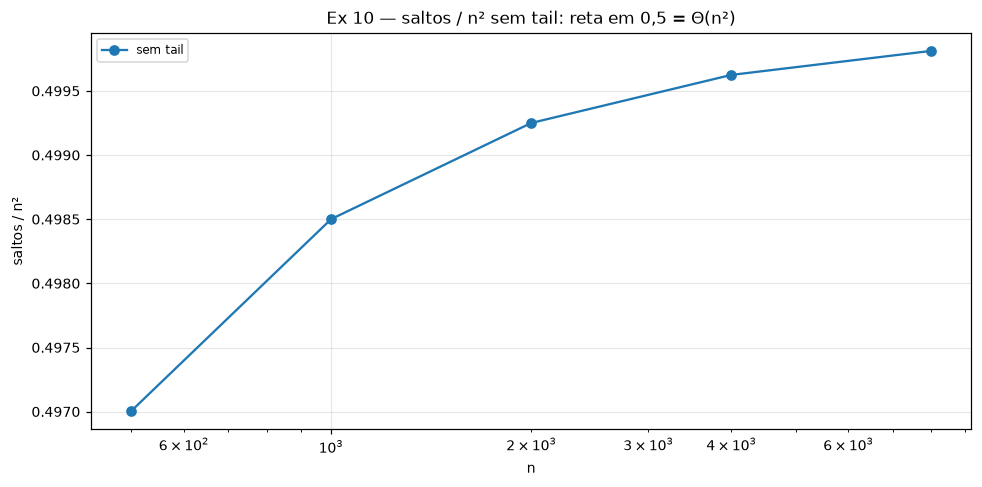

variante  com tail  sem tail  razão sem/com
n                                          
500         0.1874   16.2244        86.5763
1000        0.2072   34.3822       165.9373
2000        0.2055   68.3824       332.7611
4000        0.2162  136.6921       632.3215
8000        0.2869  289.6688     1,009.6069

COM tail: 0 saltos, Θ(1) por inserção, ~0,4 µs independente de n.
SEM tail: 31,988,001 saltos em n=8,000 — bate DÍGITO A DÍGITO com (n−1)(n−2)/2.
  razão saltos/n² sobe monotonicamente de 0.4970 a 0.4998 enquanto n cresce 16×  ⇒ Θ(n²)
  razão de tempo sem/com: 87× → 1,010×


In [6]:
sem_tail = insercoes[insercoes["variante"] == "sem tail"]
grafico_razao(sem_tail.assign(curva="sem tail"), "n", "hops/n2", "curva",
              "Ex 10 — saltos / n² sem tail: reta em 0,5 = Θ(n²)",
              "ex10_insert_last.png", "saltos / n²")

pivo_tempo = insercoes.pivot(index="n", columns="variante", values="tempo_us_por_op")
pivo_tempo["razão sem/com"] = pivo_tempo["sem tail"] / pivo_tempo["com tail"]
print(pivo_tempo.to_string())
veredito(
    "COM tail: 0 saltos, Θ(1) por inserção, ~0,4 µs independente de n.\n"
    f"SEM tail: {int(sem_tail['hops'].max()):,} saltos em n={int(sem_tail['n'].max()):,} — "
    "bate DÍGITO A DÍGITO com (n−1)(n−2)/2.\n"
    f"  razão saltos/n² sobe monotonicamente de {sem_tail['hops/n2'].min():.4f} a "
    f"{sem_tail['hops/n2'].max():.4f} enquanto n cresce 16×  ⇒ Θ(n²)\n"
    f"  razão de tempo sem/com: {pivo_tempo['razão sem/com'].min():.0f}× → "
    f"{pivo_tempo['razão sem/com'].max():,.0f}×"
)

### Análise em Big O e a justificativa da decisão

Com `tail`, `insert_last` executa **0 saltos**: Θ(1) por inserção, Θ(n) para
construir a lista. Sem `tail`, cada inserção percorre os `k−1` nós já existentes,
e o total fecha exatamente com `(n−1)(n−2)/2` — não é aproximação, a coluna
`hops_teorico` bate dígito por dígito.

A razão `saltos/n²` sobe monotonicamente para 0,5 enquanto `n` cresce 16×: razão
constante contra `n²` é a prova da classe Θ(n²). E `saltos/n`, que é o número de
saltos **por inserção**, dobra quando `n` dobra — o que descarta a hipótese de
custo constante por inserção.

**Decisão: manter o `tail`.** O custo é um atributo por lista e a correção de
`_tail` em `_unlink` ao remover o último nó — pago uma vez, na implementação. Em
troca, `insert_last` e `peek_last` caem de O(n) para O(1), e isso não é detalhe:
os exercícios 9 (partição em três listas), 4 (buckets) e 12 (listas de
ocorrências) constroem listas por anexação no fim. Sem `tail`, indexar documentos
seria quadrático no número de ocorrências por termo.

`delete` continua O(n) **mesmo com `tail`**: remover o último nó exige o
antecessor, e em lista simplesmente encadeada não há ponteiro `prev`. Esse é
exatamente o limite que o exercício 11 resolve.

In [7]:
busca_lista = pd.DataFrame(bench_search())
mostrar(busca_lista, ["n", "padrao", "buscas", "comparacoes_por_busca",
                      "comparacoes_por_busca/n", "hops", "tempo_s"],
        "BUSCA LINEAR NA LISTA — melhor, médio e pior caso")
veredito(
    "melhor caso: 1 comparação, independente de n\n"
    "caso médio : razão comparações/n entre "
    f"{busca_lista[busca_lista['padrao'].str.startswith('caso médio')]['comparacoes_por_busca/n'].min():.3f} e "
    f"{busca_lista[busca_lista['padrao'].str.startswith('caso médio')]['comparacoes_por_busca/n'].max():.3f}  (≈ n/2)\n"
    "pior caso  : razão exatamente 1,000  ⇒ Θ(n)"
)

BUSCA LINEAR NA LISTA — melhor, médio e pior caso

melhor caso: 1 comparação, independente de n
caso médio : razão comparações/n entre 0.440 e 0.562  (≈ n/2)
pior caso  : razão exatamente 1,000  ⇒ Θ(n)
